# MESSAGEix-Pakistan 
### Baseline Model
In this notebook, we are reading data and building baseline scenerio.

<img src="https://wit.lums.edu.pk/sites/default/files/inline-images/WIT_Banner.jpg" alt="Girl in a jacket" width="850" height="250">

In [1]:
# Autoreload modules when changes are applied to them
%load_ext autoreload 
%autoreload all
# Autoreload modules when changiges are applied to them
%load_ext autoreload 
%autoreload all

%reload_ext autoreload
# Set-up
# Sys and OS Operations
os.chdir("../../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


NameError: name 'os' is not defined

In [ ]:
# fundamental libraries
import os
import pandas as pd
import numpy as np
import ixmp
import message_ix
from message_ix import log


# # for reporting and visualization
# from modelFiles.plotter import plotter_MSG

# # script functions
# from modelFiles.utils import *
# from modelFiles.demand_projection import demands
# from modelFiles.adjust_capacity import adjust_capacity
# from modelFiles.national_ev_policy import ev_shares
# from modelFiles.adjust_transport import adjust_transport
# from modelFiles.current_policies import clean_shares, ARE_shares, hydro_shares
# from modelFiles.add_fuel_prices import add_fuel_prices
# from modelFiles.update_calibration import model_calibrate
# from modelFiles.adjust_activity import adjust_activity
# from modelFiles.adjust_export import adjust_exp
# from modelFiles.adjust_import import adjust_imp
# from modelFiles.adjust_renewable_potential import adjust_potential
# from modelFiles.emissions import *
# from modelFiles.update_calibration import model_calibrate

# autoreload modules when changes are applied to them
%load_ext autoreload 
%autoreload all
%reload_ext autoreload
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# saving current working directory path for later repeated use
cwd_path = os.getcwd()

Create scenario

In [ ]:
# creating ixmp platform object
new_mp = ixmp.Platform()

# creating a new, empty scenario object
scenario = message_ix.Scenario(
    new_mp, model="MESSAGEix-Pakistan", scenario="baseline", version="new"
)

2026-03-12 12:13:12,672  INFO at.ac.iiasa.ixmp.Platform:165 - Welcome to the IX modeling platform!
2026-03-12 12:13:12,675  INFO at.ac.iiasa.ixmp.Platform:166 -  connected to database 'jdbc:hsqldb:file:/Users/awais/.local/share/ixmp/localdb/default' (user: ixmp)...


Read Data

In [ ]:
data_path = "/Users/awais/Documents/GitHub/NEST-Pakistan/data/MESSAGEix-Pakistan-CurPol-SSP2-exp.xlsx"
scenario.read_excel(data_path, add_units=True, commit_steps=False, init_items=True)

##### Solve the Model

In [ ]:
log.info(f"version number before commit(): {scenario.version}")


# exporting the built model (Scenario) to GAMS with an optional case name
caseName = scenario.model + '__' + scenario.scenario + '__v' + str(scenario.version)

# solve model
scenario.solve(case=caseName)


--- Warning: The GAMS version [49.3.0] differs from the API version [24.8.3].
--- Job MESSAGE_run.gms Start 03/12/26 12:13:40 49.3.0 7de46a92 DEX-DEG x86 64bit/macOS
--- Applying:
    /Library/Frameworks/GAMS.framework/Versions/49/Resources/gmsprmun.txt
--- GAMS Parameters defined
    Input /Users/awais/Documents/GitHub/message_ix/message_ix/model/MESSAGE_run.gms
    ScrDir /Users/awais/Documents/GitHub/message_ix/message_ix/model/225b/
    SysDir /Library/Frameworks/GAMS.framework/Versions/49/Resources/
    LogOption 4
    --in /Users/awais/Documents/GitHub/message_ix/message_ix/model/data/MsgData_MESSAGEix-Pakistan__baseline__v1.gdx
    --out /Users/awais/Documents/GitHub/message_ix/message_ix/model/output/MsgOutput_MESSAGEix-Pakistan__baseline__v1.gdx
    --iter /Users/awais/Documents/GitHub/message_ix/message_ix/model/output/MsgIterationReport_MESSAGEix-Pakistan__baseline__v1.gdx
Licensee: Small MUD - 5 User License                     S240905|0002AP-GEN
          IIASA, Informatio

2026-03-12 12:13:46,571 ERROR at.ac.iiasa.ixmp.objects.Scenario:1691 - variable 'I' not found in gdx!
2026-03-12 12:13:46,574 ERROR at.ac.iiasa.ixmp.objects.Scenario:1691 - variable 'C' not found in gdx!


##### Reporting Results

In [ ]:
from report.legacy.iamc_report_hackathon import report
from datetime import datetime
import time
timestamp = f"{str(datetime.now().strftime('%Y-%m-%d--%H-%M'))}"
start = time.time()
out_dir = os.path.join(".", "output")
os.makedirs(out_dir, exist_ok=True)  # Create directory if it doesn't exist
df, path_name= report(mp=new_mp, scen=scenario, out_dir=out_dir, out_file_timestamp = timestamp, IDEA_format=False)
end = time.time()

##### Plotting Results

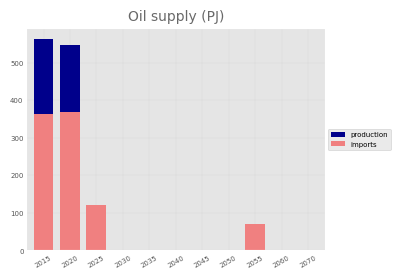

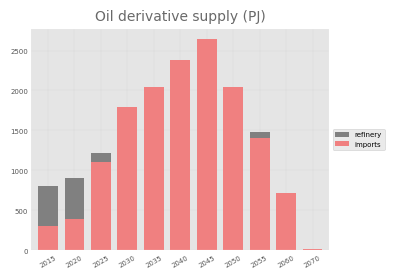

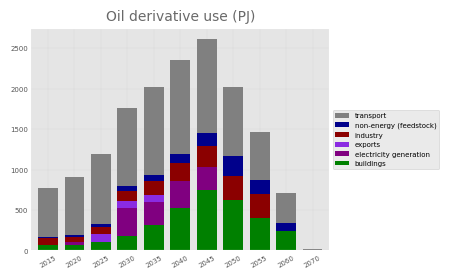

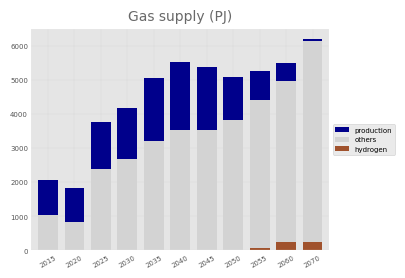

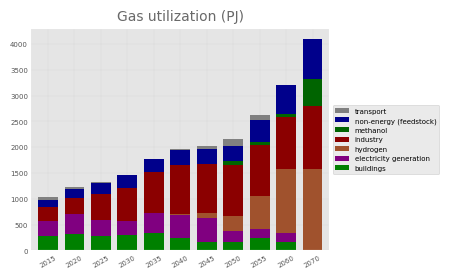

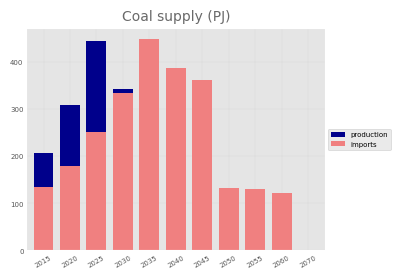

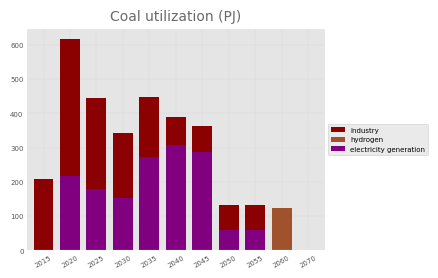

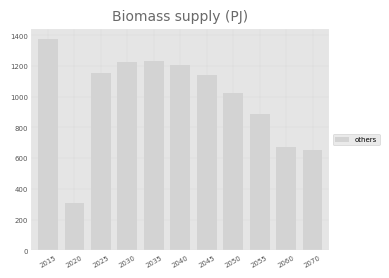

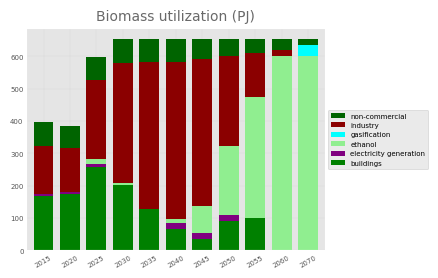

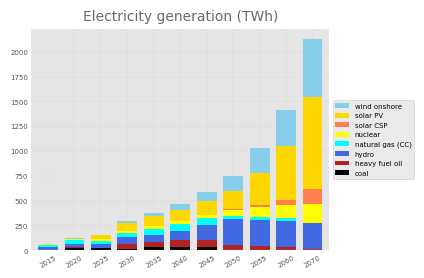

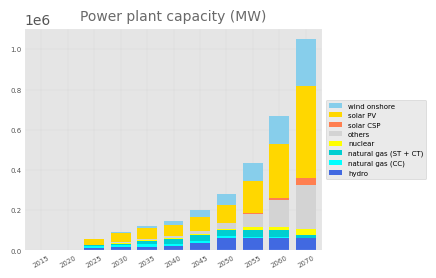

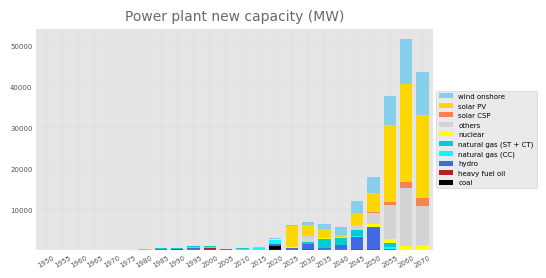

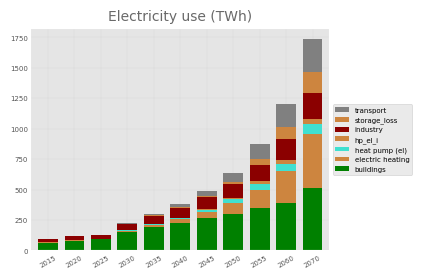

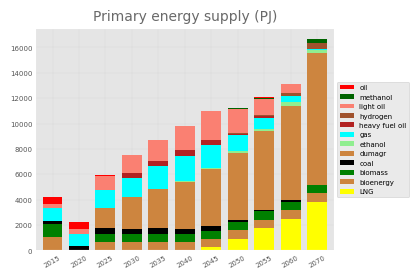

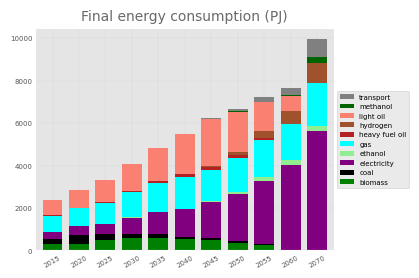

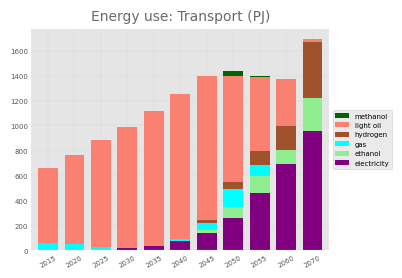

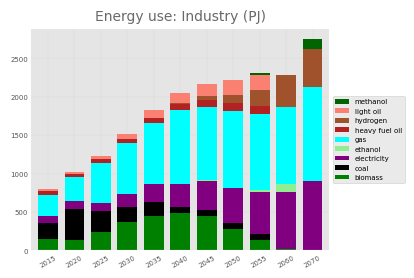

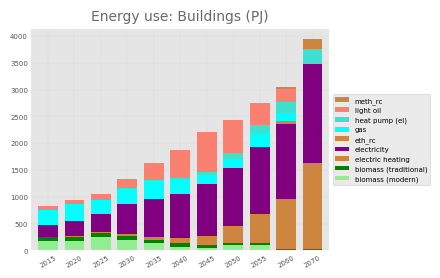

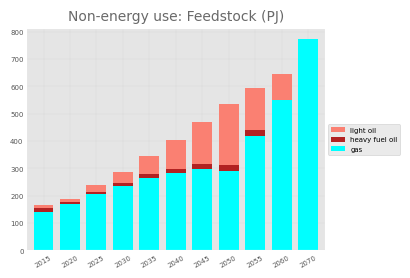

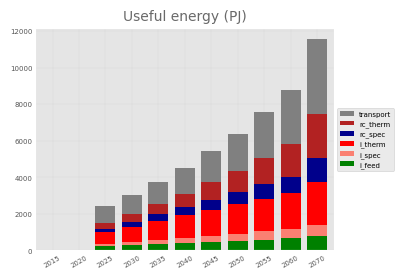

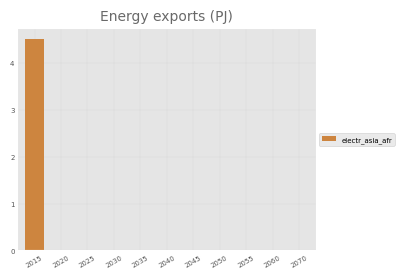

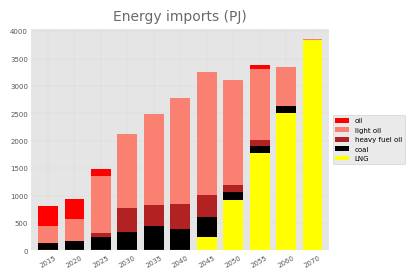

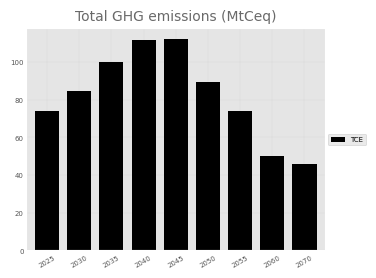

{'Electricity generation (TWh)':            coal  heavy fuel oil       hydro  natural gas (CC)     nuclear  \
 2015   0.148044        0.000000   34.632660         22.428041    4.605132   
 2020  25.966350        4.183720   38.987960         38.039688    9.897890   
 2025  21.009743        2.755041   40.375621         31.183342   23.270584   
 2030  17.885319       49.731235   63.981943         40.796684   23.920283   
 2035  33.742019       49.401577   75.648133         53.165224   31.340221   
 2040  37.617300       64.052272   97.995441         67.987233   31.231999   
 2045  35.320396       66.034726  152.164095         69.076767   31.231999   
 2050   5.834236       43.526540  262.800000         32.060367   64.081999   
 2055   5.834236       37.942991  262.800000         28.791665   96.931999   
 2060   0.000000       31.778301  262.800000         28.277751  129.781999   
 2070   0.000000       12.054221  262.800000          0.000000  195.481999   
 
        solar CSP    solar PV 

In [ ]:
path = os.path.join(cwd_path, "output", "plots")
os.makedirs(path, exist_ok=True)  # Create directory if it doesn't exist
plotter = plotter_MSG(scenario)
plotter.plotter(caseName, nodeloc=["R12_PAK"], path=path, yr_min=2015, yr_max=2070)

In [ ]:
scenario.set("cat_tec")

,type_tec,technology
0,investment_electricity,bio_istig_ccs
1,investment_electricity,bio_ppl
2,investment_electricity,bio_ppl_co2scr
3,investment_electricity,c_ppl_co2scr
4,investment_electricity,cement_co2scr
...,...,...
827,renewable_total,oil_ppl
828,renewable_total,hydro_hc
829,renewable_total,hydro_lc
830,renewable_total,nuc_hc


In [ ]:
# close the connection to the database
new_mp.close_db() 

In [ ]:
new_mp.open_db()